<a href="https://colab.research.google.com/github/sandyzayn/Amazon_churn_data/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/amazon_churn_dataset_large.csv")

In [3]:
df.head()

,CustomerID,Age,MonthlySpend,Tenure,NumOrders,Churn
0,1001,56,86,45,5,0
1,1002,46,418,42,16,0
2,1003,32,744,25,1,0
3,1004,25,574,18,14,0
4,1005,38,328,40,15,0


In [4]:
df.describe()

,CustomerID,Age,MonthlySpend,Tenure,NumOrders,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,1250.500000,39.326000,407.832000,25.274000,9.952000,0.04200
std,144.481833,12.200386,222.351957,13.482674,5.437355,0.20079
min,1001.000000,18.000000,50.000000,1.000000,1.000000,0.00000
25%,1125.750000,29.000000,214.000000,14.000000,5.000000,0.00000
50%,1250.500000,41.000000,399.000000,26.000000,10.000000,0.00000
75%,1375.250000,50.000000,595.250000,37.000000,15.000000,0.00000
max,1500.000000,59.000000,799.000000,47.000000,19.000000,1.00000


In [5]:
print(df.shape[0],"no of rows")
print(df.shape[1],"no of columns")

500 no of rows
6 no of columns


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
# Features and Target
X = df[['Age','MonthlySpend','Tenure','NumOrders']]
y = df['Churn']

In [9]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
# Prediction
y_pred = model.predict(X_test)

In [12]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)


In [13]:
print("Accuracy:", accuracy)


Accuracy: 0.95


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        98
           1       0.00      0.00      0.00         2

    accuracy                           0.95       100
   macro avg       0.49      0.48      0.49       100
weighted avg       0.96      0.95      0.95       100



In [15]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[95  3]
 [ 2  0]]


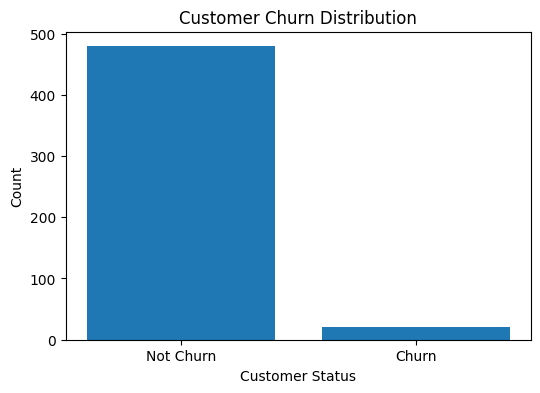

In [16]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Not Churn','Churn'], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Count")
plt.show()
